# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 35     |  |
| :-------------|:-------------|
| Kimi Hekmat| 6534759 |
| Sebas van den Akker| 6562892 |
| Carsten Schroevers | 6126634 |

## Opdracht 1: Planning.

| Planning Groep: 35     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 12:00 klaar | Carsten |
| ontwerp-eis berekenen| 12:00 | Kimi en Sebas|
| activiteit 1 | 12:00 | hele groep - individuele werk klaar |
| activiteit 2 | 12:30 | hele groep - alles besproken |
| Mijlpaal 1 | 12:30 | Werkend ontwerp hebben |
| Mijlpaal 2 | 15:00 | Klaar met de eerste iteratie|
| Pauze 1| 12:30 - 13:30 | hele groep |
| Pauze 2| 17:00-17:10 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 4 |
| hoe lang voor één meting | Maximaal 5 minuten |
| verwacht nauwkeurigheid meting | Afwijking frequentie: 0.1Hz, Amplitude: 0.1 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie

f0 = (5/2) #Hz

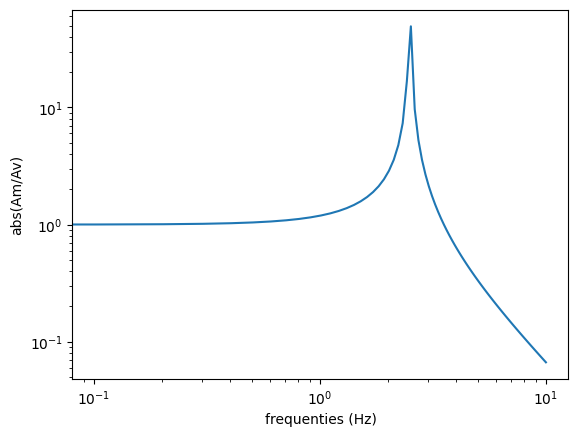

In [3]:
# Voeg hier je plot in.

def amplitudes(f):
    return 1/(1-(((2*np.pi*f)/(2*np.pi*f0)))**2)

freqs = np.linspace(0, 10, 100)

plt.figure()
plt.plot(freqs, np.abs(amplitudes(freqs)), '-')
plt.xlabel("frequenties (Hz)")
plt.ylabel("abs(Am/Av)")
plt.xscale('log')
plt.yscale('log')
plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.

delta_x_min = 9.81/((2*np.pi*f0)**2)
print(delta_x_min)

0.039758432461253344


De delta x die we hebben berekend is een minimale eis. Als deze groter is, zal w0 kleiner zijn, wat zal zorgen voor een grotere demping. We gaan dus mikken op een delta x groter dan 4 cm

## Opdracht 3: Plot de grafiek.

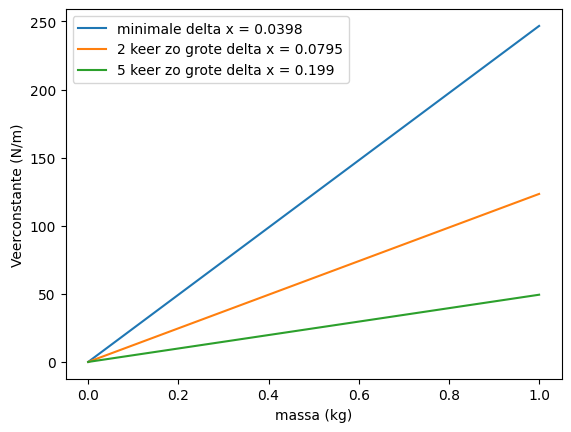

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

def constante(m, deltax):
    return (m*9.81)/deltax

m = np.linspace(0, 1, 100)

plt.figure()
plt.plot(m, constante(m, delta_x_min), '-', label = f'minimale delta x = {delta_x_min:.3g}')
plt.plot(m, constante(m, 2*delta_x_min), '-', label = f'2 keer zo grote delta x = {2*delta_x_min:.3g}')
plt.plot(m, constante(m, 5*delta_x_min), '-', label = f'5 keer zo grote delta x = {5*delta_x_min:.3g}')
plt.xlabel("massa (kg)")
plt.ylabel("Veerconstante (N/m)")
plt.legend()
plt.savefig("deltax.png")
plt.show()


## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Een veer te kiezen met een lagere veerconstante, dus een slappere veer
- De massa te verhogen op de veer

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 7.9 centimeter, dus 2 keer zo groot als de minimale waarde. We doen dit omdat we niet te dichtbij de minimale waarde willen zitten maar ook niet te ver daarvanaf, dan wordt het balanseren van de veerconstante en de massa namelijk moeilijk.

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="trillingopstellingFINAL.jpeg" width="400">

Als verend mechanisme gaan we elastiekjes aan elkaar haken en hieraan een massa verbinden die bestaat uit steentjes die we aan elkaar getapet hebben.
Zoals in de schets staat gaan we delta x mikken op 8 cm minimaal.

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

8 cm 

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja, onze delta x is nu ongeveer 15 cm
De rustlengte was namelijk 35 cm, met massa was hij 50 cm. Dus delta x is 15 cm

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Na het indrukken en uitrekken van het elastiek lijkt dat met de massa eraan ongeveer 20 cm uitrekking de max is totdat het elastiek niet-lineair gedrag gaat vormen.

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Als we kijken naar de opstelling lijkt het dat het elastiek nu niet meer dan ongeveer 4 cm oscilleert. Dus dat zit onder de grens voor niet-lineair gedrag. We kunnen straks dus metingen doen.

### Gaat je ontwerp dus voldoen aan de eis?

Delta x zit ruim boven de minimum waarde, en de amplitude van de trilling zit in het lineaire bereik. We verwachten dus dat het ontwerp zal voldoen aan de eis.

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

1.2870902658913332


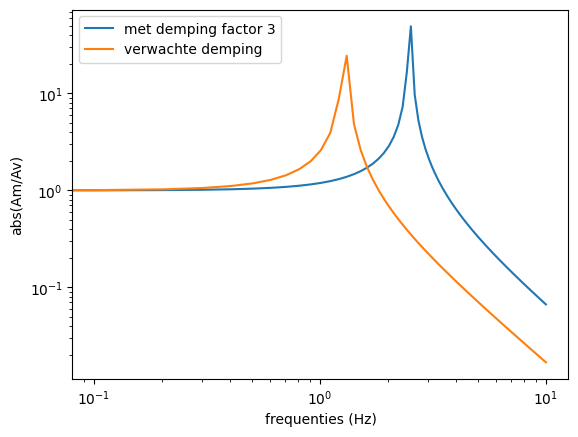

In [6]:
# Voeg hier je plot in.
w0 = np.sqrt(9.81/0.15) #0.15 is hier delta x die we bereiken
f_0 = w0/(2*np.pi)
print(f_0)

def amplitudes2(f):
    return 1/(1-(((2*np.pi*f)/(2*np.pi*f_0)))**2)

plt.figure()
plt.plot(freqs, np.abs(amplitudes(freqs)), '-', label = 'met demping factor 3')
plt.plot(freqs, np.abs(amplitudes2(freqs)), '-', label = 'verwachte demping')
plt.xlabel("frequenties (Hz)")
plt.ylabel("abs(Am/Av)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

## Opdracht 7: Plotten maar

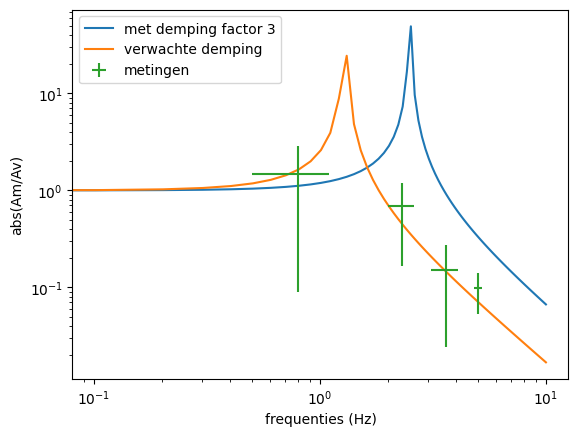

In [7]:
# Voeg hier je plots in.

gemeten_f = np.array([3.6, 5, 0.8, 2.3])
u_gemeten_f = np.array([0.5, 0.2, 0.3, 0.3])

Am = np.array([0.3, 0.45, 1.33, 0.8])
u_Am = np.array([0.25, 0.2, 0.7, 0.5])

Av = np.array([2, 4.6, 0.9, 1.17])
u_Av = np.array([0.2, 0.4, 0.7, 0.5])

verhouding = np.abs(Am/Av)

def error_verhouding(Av, uAv, Am, uAm, verh):
    return np.sqrt(((uAm/Am)**2) + ((uAv/Av)**2)) * verh

u_verhouding = error_verhouding(Av, u_Av, Am, u_Am, verhouding)

plt.figure()
plt.plot(freqs, np.abs(amplitudes(freqs)), '-', label = 'met demping factor 3')
plt.plot(freqs, np.abs(amplitudes2(freqs)), '-', label = 'verwachte demping')
plt.errorbar(gemeten_f, verhouding, xerr = u_gemeten_f, yerr = u_verhouding, label = 'metingen', linestyle = 'none')
plt.xlabel("frequenties (Hz)")
plt.ylabel("abs(Am/Av)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.savefig('metingen.jpeg')
plt.show()


## Iteratie

Onze opstelling werkt heel goed, zoals te zien is in  de grafiek hierboven. Echter is er ruimte voor verbetering door de trilling in de x en y richting te stabiliseren. Daarom doen we nog 1 iteratie.

We gaan dit doen door de draden van de arduino aan 1 kant vast te tapen, want de trilling daarvan zorgt ervoor dat de massa draait
Ook maken we van de opstelling een double pendulum, de onderste massa zal de sensor terugtrekken als deze uit evenwicht gebracht wordt. Zie schets.

<img src="iteratietrilling.jpeg" width="400">

Verder blijven de antwoorden bij opdracht 6 evaluatie hetzelfde, dus dit gaan we niet aanpassen.

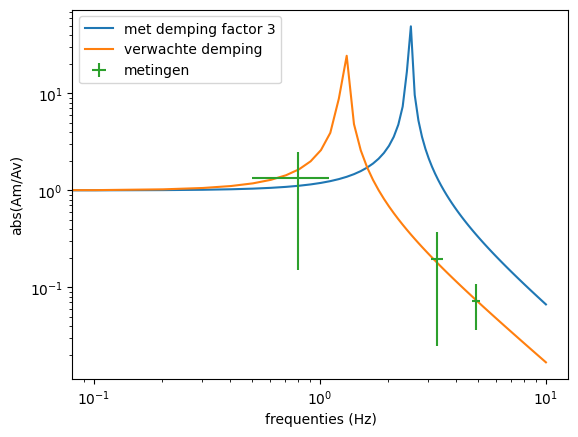

In [8]:
gemeten_f2 = np.array([4.9, 0.8, 3.3])
u_gemeten_f2 = np.array([0.2, 0.3, 0.2])

Am2 = np.array([0.40, 1.20, 0.35])
u_Am2 = np.array([0.2, 0.7, 0.3])

Av2 = np.array([5.5, 0.9, 1.77])
u_Av2 = np.array([0.3, 0.6, 0.3])

verhouding2 = np.abs(Am2/Av2)

def error_verhouding(Av, uAv, Am, uAm, verh):
    return np.sqrt(((uAm/Am)**2) + ((uAv/Av)**2)) * verh

u_verhouding2 = error_verhouding(Av2, u_Av2, Am2, u_Am2, verhouding2)

plt.figure()
plt.plot(freqs, np.abs(amplitudes(freqs)), '-', label = 'met demping factor 3')
plt.plot(freqs, np.abs(amplitudes2(freqs)), '-', label = 'verwachte demping')
plt.errorbar(gemeten_f2, verhouding2, xerr = u_gemeten_f2, yerr = u_verhouding2, label = 'metingen', linestyle = 'none')
plt.xlabel("frequenties (Hz)")
plt.ylabel("abs(Am/Av)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.savefig('metingen2.jpeg')
plt.show()

De grafieken lijken best veel op elkaar, maar het is zichtbaar dat na de iteratie onze verwachting net iets beter benaderd word. De iteratie is dus geslaagd!

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

## Leerdoel 1: inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen

<img src="deltax.png" width="400">

## Leerdoel 2: Op basis van een differentiaalvergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp

<img src="metingen_iteratie.jpeg" width="400">